# PS-S06E02: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_feature_engineering import FeatureFactory
from ps_s06e02_model_visualizer import ModelVisualizer
from ps_s06e02_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Heart Disease'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'one_hot_encoding',
    'interactions',
    'bins',
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 14
New Feature Count: 62
   Age   BP  Cholesterol  Max HR  ST depression  Theoretical_Max_HR  \
0   58  152          239     158          3.600                 162   
1   52  125          325     171          0.000                 168   
2   56  160          188     151          0.000                 164   
3   44  134          229     150          1.000                 176   
4   58  140          234     125          3.800                 162   

   HR_Deficiency  Cholesterol_Age_Ratio  BP_Age_Factor  \
0              4                  4.051           8816   
1             -3                  6.132           6500   
2             13                  3.298           8960   
3             26                  5.089           5896   
4             37                  3.966           8120   

   Angina_Pain_Interaction  Sex_0  Sex_1  Chest pain type_1  \
0                        4      0      1                  0   
1             

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

In [7]:
n_jobs = 1 if USE_GPU else -1

# Convert object columns to 'category' dtype
X_rfe = X.copy()

cat_cols = X_rfe.select_dtypes(include=['category']).columns.tolist()
for col in cat_cols:
    X_rfe[col] = X_rfe[col].cat.codes.astype('int16')

obj_cols = X_rfe.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes.astype('int16')

if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')
    
    # Use a conservative estimator for selection
    # High depth, moderate learning rate to find signal quickly
    clf = xgb.XGBClassifier(
        n_estimators=1000, 
        learning_rate=0.05, 
        max_depth=6, 
        colsample_bytree=0.8,
        reg_alpha=0.1,
        tree_method='hist',
        enable_categorical=True,
        device='cpu',
        random_state=seed,
        n_jobs=n_jobs
    )

    # Use 'neg_root_mean_squared_error' for regression
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=KFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='neg_root_mean_squared_error', 
        min_features_to_select=15,
        n_jobs=n_jobs
    )

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns
        
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Theoretical_Max_HR', 'HR_Deficiency', 'Cholesterol_Age_Ratio', 'BP_Age_Factor', 'Angina_Pain_Interaction', 'Sex_0', 'Sex_1', 'Chest pain type_1', 'Chest pain type_2', 'Chest pain type_3', 'Chest pain type_4', 'FBS over 120_0', 'FBS over 120_1', 'EKG results_0', 'EKG results_1', 'EKG results_2', 'Exercise angina_0', 'Exercise angina_1', 'Slope of ST_1', 'Slope of ST_2', 'Slope of ST_3', 'Number of vessels fluro_0', 'Number of vessels fluro_1', 'Number of vessels fluro_2', 'Number of vessels fluro_3', 'Thallium_3', 'Thallium_6', 'Thallium_7', 'Age_bin_0', 'Age_bin_1', 'Age_bin_2', 'Age_bin_3', 'Age_bin_4', 'Age_bin_5', 'BP_bin_0', 'BP_bin_1', 'BP_bin_2', 'BP_bin_3', 'BP_bin_4', 'BP_bin_5', 'BP_bin_6', 'Cholesterol_bin_0', 'Cholesterol_bin_1', 'Cholesterol_bin_2', 'Cholesterol_bin_3', 'Cholesterol_bin_4', 'Cholesterol_bin_5', 'Cholesterol_bin_6', 'Cholesterol_bin_7', 'Cholest

In [8]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),
        
        # Tree Structure
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Boilerplate for Classification
        'objective': 'binary:logistic',
        'eval_metric': 'auc',              # <--- Metric to optimize
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    y_encoded = y.map({'Absence': 0, 'Presence': 1})
    
    # Ensure optimal_cols is a standard list for filtering
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    cv_auc = []

    # Standard CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y_encoded)):
        
        # Create Folds
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y_encoded.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y_encoded.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
        obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
        for col in obj_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        # Create model (Classifier)
        model = xgb.XGBClassifier(**param)

        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        val_prob = model.predict_proba(X_val_trans)[:, 1]
        
        # Score this fold
        fold_score = roc_auc_score(y_val_fold, val_prob)
        cv_auc.append(fold_score)

    # Return the average ROC AUC across all folds
    return np.mean(cv_auc)


In [9]:
if PERFORM_OPTUNA_TUNING:
    print('Starting XGBoost Optuna Optimization (ROC AUC)...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
    
    study_xgb = optuna.create_study(
        direction='maximize',
        study_name='xgb_predicting_heart_disease_optuna', 
        pruner=pruner
    )
    
    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'   ROC AUC: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)
    
    xgb_best_params = study_xgb.best_params
else:
    xgb_best_params = {
        'learning_rate': 0.040832690301036326,
        'max_depth': 3,
        'min_child_weight': 11.284146233264028,
        'subsample': 0.7858312427346048,
        'colsample_bytree': 0.6597791637334759,
        'reg_alpha': 0.03784493216565626,
        'reg_lambda': 0.34676876406973234,
        'gamma': 0.45046145857532416,
        'grow_policy': 'lossguide'
    }
    
    print('\nUsing earlier calculated params:')
    print('  Params: ', xgb_best_params)


[I 2026-02-11 16:58:17,333] A new study created in memory with name: xgb_predicting_heart_disease_optuna


Starting XGBoost Optuna Optimization (ROC AUC)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-11 17:01:39,245] Trial 0 finished with value: 0.9553783083999658 and parameters: {'learning_rate': 0.025058067673036304, 'max_depth': 3, 'min_child_weight': 1.2709842435916907, 'subsample': 0.5592078420648867, 'colsample_bytree': 0.5842801923558563, 'reg_alpha': 0.055900033261578094, 'reg_lambda': 0.06941857840710808, 'gamma': 0.5028270350070464, 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.9553783083999658.
[I 2026-02-11 17:04:20,386] Trial 1 finished with value: 0.9553825973710002 and parameters: {'learning_rate': 0.03314925237442427, 'max_depth': 3, 'min_child_weight': 2.264698189777287, 'subsample': 0.5432619797219075, 'colsample_bytree': 0.9337957830966058, 'reg_alpha': 0.3557823798964767, 'reg_lambda': 8.269875334558925, 'gamma': 0.5234264735533908, 'grow_policy': 'lossguide'}. Best is trial 1 with value: 0.9553825973710002.
[I 2026-02-11 17:06:45,488] Trial 2 finished with value: 0.9553490950541794 and parameters: {'learning_rate': 0.038054357769410796, 

## Model Training

In [10]:
xgb_tuned_params = {
    **xgb_best_params, # Unpack Optuna best params
    'n_estimators': 8000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'enable_categorical': True,      # Native categorical support
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist' if USE_GPU else 'hist',
}

print('Final XGBoost CV Training with OOF / Test probabilities')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

y_encoded = y.map({'Absence': 0, 'Presence': 1}).astype(np.int8)

# Initialize Standard K-Fold
n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros(len(y_encoded))
test_probs = np.zeros(len(test_df))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y_encoded)):
    print(f'Starting processing of fold {fold+1}')

    # Create Folds
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y_encoded.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y_encoded.iloc[val_idx]
    
    # Feature Engineering
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
    obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
    for col in obj_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    # Create model (Classifier)
    model = xgb.XGBClassifier(**xgb_tuned_params)
    
    # Train Model
    model.fit(
        X_train_trans, y_train_fold,
        # eval_set order: [train, validation] so we can track both
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        verbose=500
    )
    
    # Store history
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict OOF probabilities
    val_prob = model.predict_proba(X_val_trans)[:, 1]
    oof_probs[val_idx] = val_prob
    
    # Score this fold
    fold_auc = roc_auc_score(y_val_fold, val_prob)
    print(f'Fold {fold+1} ROC-AUC: {fold_auc:.5f} (best_iteration={model.best_iteration})')
    
    # Accumulate Test Probs
    test_prob_fold = model.predict_proba(X_test_trans)[:, 1]
    test_probs += test_prob_fold / n_folds

# Final Metric Calculation
overall_auc = roc_auc_score(y_encoded, oof_probs)
print(f"Overall CV ROC-AUC: {overall_auc:.5f}")

Final XGBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.040832690301036326, 'max_depth': 3, 'min_child_weight': 11.284146233264028, 'subsample': 0.7858312427346048, 'colsample_bytree': 0.6597791637334759, 'reg_alpha': 0.03784493216565626, 'reg_lambda': 0.34676876406973234, 'gamma': 0.45046145857532416, 'grow_policy': 'lossguide', 'n_estimators': 8000, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'n_jobs': 1, 'random_state': 10301, 'enable_categorical': True, 'early_stopping_rounds': 100, 'tree_method': 'gpu_hist'}
Starting processing of fold 1
[0]	validation_0-auc:0.87211	validation_1-auc:0.87129
[500]	validation_0-auc:0.95490	validation_1-auc:0.95544
[1000]	validation_0-auc:0.95572	validation_1-auc:0.95599
[1500]	validation_0-auc:0.95610	validation_1-auc:0.95611
[2000]	validation_0-auc:0.95635	validation_1-auc:0.95614
[2469]	validation_0-auc:0.95654	validation_1-auc:0.95615
Fold 1 ROC-AUC: 0.95616 (best_iteration=2369)
Startin

## Visualizing Model Performance
We use four key plots to diagnose the health of our classification model

### Learning Curves (Train vs. Validation AUC)
This plot tracks the **Area Under the ROC Curve (AUC)** for both the training set (Blue) and validation set (Red) over each boosting iteration.

* **What to look for:** You want the Validation (Red) curve to go **up** and flatten out at a high value (closer to 1.0).down and flatten out.
* **Overfitting:** If the Blue line keeps rising rapidly towards 1.0 but the Red line stops improving or starts dropping, the model is memorizing the training data instead of generalizing.
* **Underfitting:** If both lines remain low and flat, the model isn't learning enough complexity to distinguish between classes.
* **Ideal:** The Red line reaches a maximum high value and stays stable. The gap between the Blue (Train) and Red (Validation) curves should not be massive.

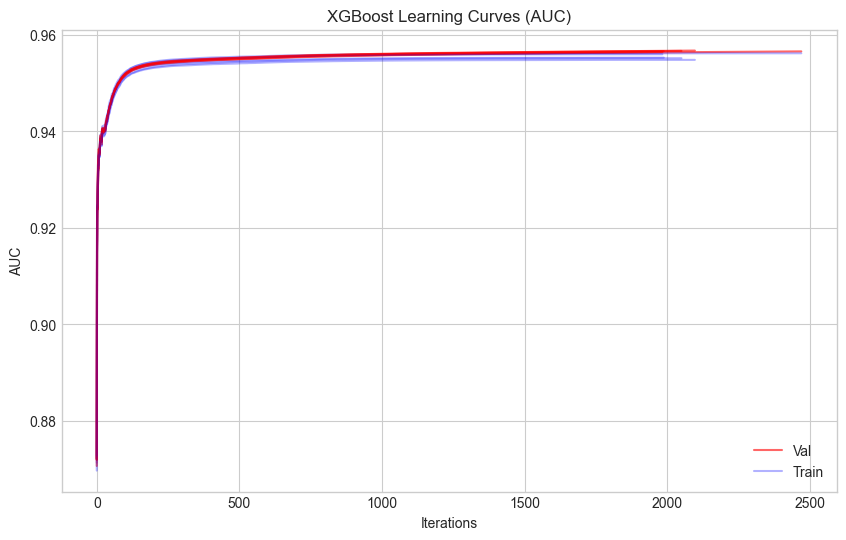

In [11]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results, metric='auc')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features make sense (e.g., `study_hours` or `class_attendance` should likely be high).
* **Sanity Check:** If `id` or a random noise column appears in the top 5, there is a data leakage problem.
* **Engineering Check:** Look for the engineered features (e.g., `restoration_index`, `interaction_score`). If they appear near the top, the feature engineering added real value.

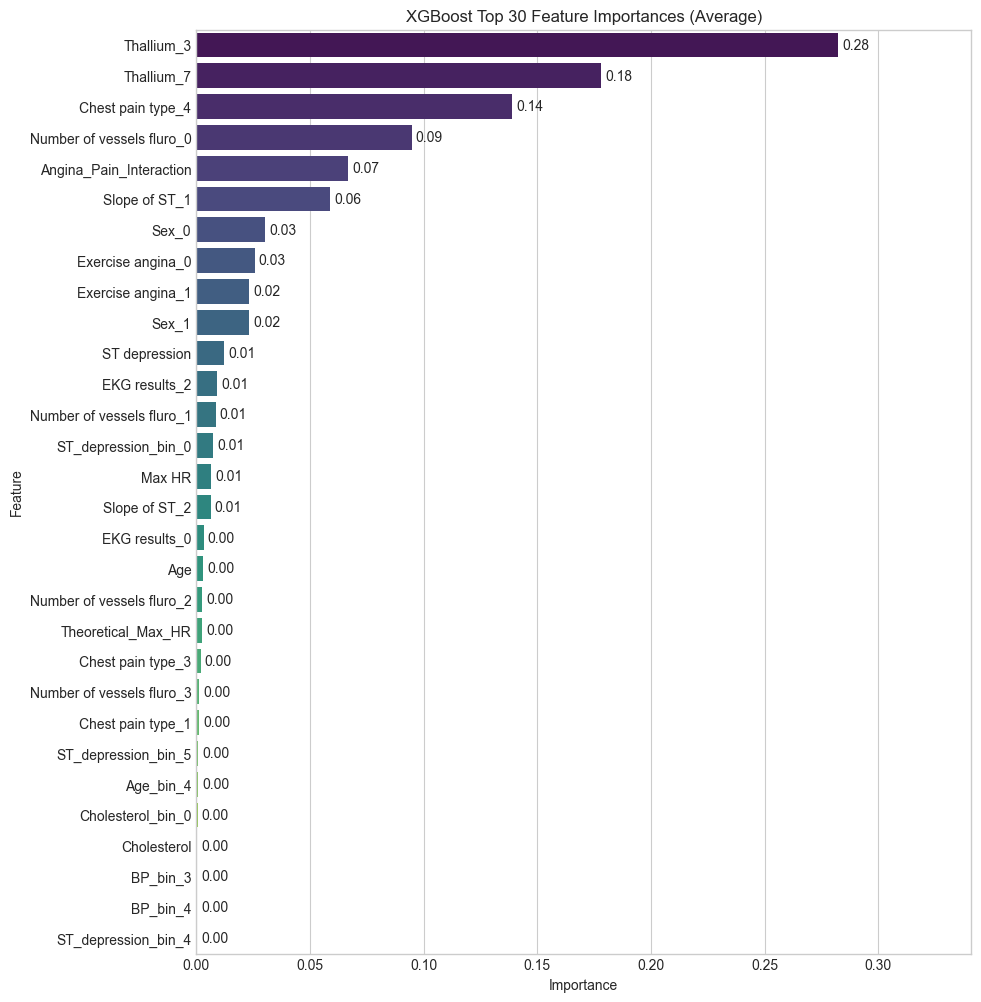

In [12]:
mviz.plot_feature_importance(models, show_values=True)

### Confusion Matrix
The **Confusion Matrix** provides a detailed breakdown of the model's performance by showing how many instances were correctly and incorrectly classified for each class.
* **True Negatives (Top-Left):** Patients who **do not** have heart disease, and the model correctly predicted **Absence**.
* **False Positives (Top-Right):** Patients who **do not** have heart disease, but the model incorrectly predicted **Presence** (Type I Error).
* **False Negatives (Bottom-Left):** Patients who **do** have heart disease, but the model incorrectly predicted **Absence** (Type II Error). *In medical diagnostics, this is often the most critical error to minimize.*
* **True Positives (Bottom-Right):** Patients who **do** have heart disease, and the model correctly predicted **Presence**.

Normalized confusion matrix


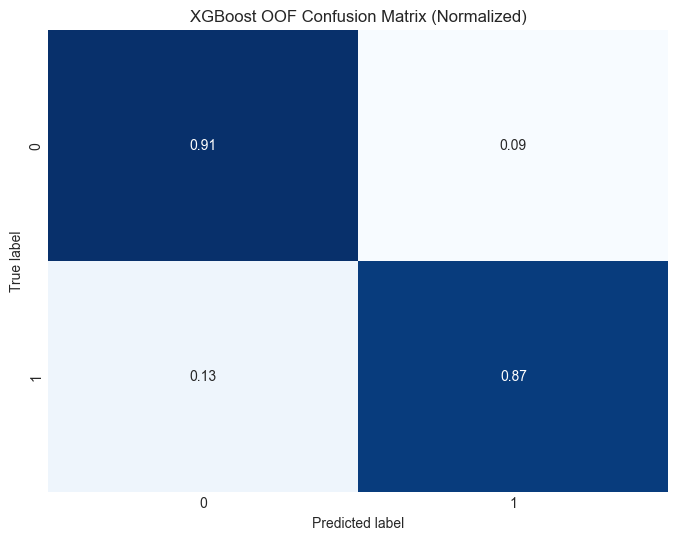

In [13]:
# Convert probabilities to hard classes (0 or 1) using a standard 0.5 threshold
y_pred_class = (oof_probs > 0.5).astype(int)

mviz.plot_confusion_matrix(y_encoded, y_pred_class, classes=[0, 1], normalize=True, title='XGBoost OOF Confusion Matrix (Normalized)')

### ROC Curve & AUC
The **Receiver Operating Characteristic (ROC)** curve illustrates the diagnostic ability of our binary classifier system as its discrimination threshold is varied.
* **The Plot:** It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)**.
* **The Goal:** We want the blue line to hug the top-left corner as closely as possible, maximizing the area under it.
* **AUC Score:** The **Area Under the Curve (AUC)** summarizes the curve into a single number between 0.5 (random guessing) and 1.0 (perfect classification). This is the primary evaluation metric for this competition.

<Figure size 800x600 with 0 Axes>

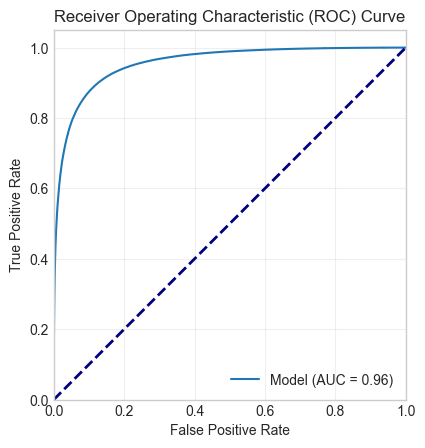

In [14]:
mviz.plot_roc_curve(y_encoded, oof_probs)

## Prepare Submission

In [15]:
submission_df = helper.read_dataset('submission')
submission_df[TARGET] = test_probs

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  Heart Disease
0  630000          0.950
1  630001          0.009
2  630002          0.989
3  630003          0.005
4  630004          0.201
5  630005          0.983
6  630006          0.005
7  630007          0.621
8  630008          0.992
9  630009          0.012


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [17]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_xgb': oof_probs,
    'target': y_encoded.values
})
oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

test_pred_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_xgb': test_probs
})
test_pred_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_probs.csv, {output_dir}/xgb_test_probs.csv')

Saved for Blending: predictions/xgb_oof_probs.csv, predictions/xgb_test_probs.csv
